# Global Forces

Notebook to generate the timeseries of building's global forces, generated from its pressure measurements.

## Input Variables

In [2]:
import pathlib
import h5py
import numpy as np
import pandas as pd
from dataclasses import dataclass

In [5]:
# Path for timeseries of body's pressure
body_xdmf = "/home/ubuntu/Documents/Codigos/AeroSim/cfdmod/fixtures/tests/pressure/caarc/bodies.body_Body Pressure.xdmf"
body_h5 = "/home/ubuntu/Documents/Codigos/AeroSim/cfdmod/fixtures/tests/pressure/caarc/bodies.body_Body Pressure.h5"

# Path for atmosphere probe (leve as None in case it wasn't exported)
atm_xdmf = "/home/ubuntu/Documents/Codigos/AeroSim/cfdmod/fixtures/tests/pressure/caarc/points.point_Reference Probe.xdmf"
atm_h5 = "/home/ubuntu/Documents/Codigos/AeroSim/cfdmod/fixtures/tests/pressure/caarc/points.point_Reference Probe.h5"

# Path to save CSV with global moments and forces
export_csv = "/home/ubuntu/Documents/Codigos/AeroSim/cfdmod/fixtures/tests/pressure/caarc/forces_per_floor.csv"

floors_max_height = np.linspace(3, 180, (180-3)//3+1, endpoint=True)
print(floors_max_height)
print(floors_max_height.shape)

# Reference values to use for Cp
reference_velocity = 10 # m/s
fluid_density = 1.225

# Lever for MZ
lever_position = (0, 0, 0)
# Nominal area for Cf
nominal_area = 30*180
# Nominal volume for Cm
nominal_volume = 30*30*180

[  3.   6.   9.  12.  15.  18.  21.  24.  27.  30.  33.  36.  39.  42.
  45.  48.  51.  54.  57.  60.  63.  66.  69.  72.  75.  78.  81.  84.
  87.  90.  93.  96.  99. 102. 105. 108. 111. 114. 117. 120. 123. 126.
 129. 132. 135. 138. 141. 144. 147. 150. 153. 156. 159. 162. 165. 168.
 171. 174. 177. 180.]
(60,)


## Functions

In [13]:
def add_cp2xdmf(
    *,
    body_h5: pathlib.Path,
    atm_probe_h5: pathlib.Path | None,
    reference_vel: float,
    fluid_density: float,
):
    """Add pressure coefficient (Cp) to H5 compatible with XDMF format

    Args:
        body_h5 (pathlib.Path): path to .h5 file for body's pressure time series
        atm_probe_h5 (pathlib.Path | None): path to .h5 file for atmospheric pressure probe.
            If None consider constant atmospheric pressure of 0.
        reference_vel (float): reference velocity to use
        fluid_density (float): fluid density to use
    """

    with h5py.File(body_h5, mode="a") as f_body:
        grp_abs = f_body["pressure"]
        grp_cp = f_body.require_group("cp")
        keys = list(grp_abs.keys())

        if atm_probe_h5 is None:
            for k in keys:
                p_body = grp_abs[k]
                cp = (p_body) / (0.5 * fluid_density * reference_vel**2)
                if k in grp_cp:
                    del grp_cp[k]
                grp_cp[k] = cp
            return

        with h5py.File(atm_probe_h5) as f_atm:
            grp_atm = f_atm[f"pressure"]
            for k in keys:
                p_body = grp_abs[k]
                p_ref = grp_atm[k][0]
                cp = (p_body - p_ref) / (0.5 * fluid_density * reference_vel**2)
                if k in grp_cp:
                    del grp_cp[k]
                grp_cp[k] = cp


@dataclass
class GeomTriangles:
    """Class to represent a triangulated geometry"""
    triangles: np.ndarray
    centers: np.ndarray
    areas: np.ndarray
    normals: np.ndarray

def geometry_from_h5(body_h5: pathlib.Path) -> GeomTriangles:
    """Get the geometry from body's .h5 file"""

    with h5py.File(body_h5, mode="r") as f_body:
        triangles_idx = np.array(f_body["Triangles"]).flatten()
        vertices = np.array(f_body["Geometry"])

        triangles = vertices[triangles_idx]
        triangles = triangles.reshape(f_body["Triangles"].shape + (3, ))

    U = triangles[:, 1, :] - triangles[:, 0, :]
    V = triangles[:, 2, :] - triangles[:, 0, :]
    cross_prod = np.cross(U, V)
    areas = np.linalg.norm(cross_prod, axis=1) / 2
    normals = cross_prod / np.linalg.norm(cross_prod, axis=1)[:, np.newaxis]
    centers = triangles.mean(axis=1)
    return GeomTriangles(triangles=triangles, areas=areas, normals=normals, centers=centers)


def get_global_timeseries_forces_per_height(*, body_h5: pathlib.Path, geometry: GeomTriangles, nominal_area: float, nominal_volume: float, floors_max_height: np.ndarray) -> pd.DataFrame:
    """Calculate global forces on building floors from pressure coefficients and geometry"""

    lever_dist = geometry.centers - np.array(lever_position)
    lever = np.linalg.norm(lever_dist, axis=1)
    nx, ny = geometry.normals[:, 0], geometry.normals[:, 1]
    heights = geometry.centers[:, 2]
    floor_index = np.searchsorted(floors_max_height, heights, side="right")
    n_floors = len(floors_max_height)

    with h5py.File(body_h5) as f_body:
        grp_cp = f_body["cp"]
        keys = list(grp_cp.keys())
        n_steps = len(keys)

    df_dct = {k: np.empty((n_floors*n_steps)) for k in ("time_step", "floor", "fx", "fy", "mz")}

    with h5py.File(body_h5) as f_body:
        grp_cp = f_body["cp"]
        keys = list(grp_cp.keys())

        for i, k in enumerate(keys):
            # key in format of (t{time_value})
            time_step = float(k[1:])

            cp = grp_cp[k] * geometry.areas
            # Force and moments by triangle
            fx = cp * nx / nominal_area
            fy = cp * ny / nominal_area
            mz = (cp * ny - cp * nx) * lever / nominal_volume

            # Aggregate per floor
            fx_floors = np.bincount(floor_index, weights=fx, minlength=n_floors)
            fy_floors = np.bincount(floor_index, weights=fy, minlength=n_floors)
            mz_floors = np.bincount(floor_index, weights=mz, minlength=n_floors)

            # Append to global dictionary
            # Store results
            for n_floor in range(n_floors):
                df_dct["time_step"][i + n_floor * n_steps] = time_step
                df_dct["floor"][i + n_floor * n_steps] = n_floor
                df_dct["fx"][i + n_floor * n_steps] = fx_floors[n_floor]
                df_dct["fy"][i + n_floor * n_steps] = fy_floors[n_floor]
                df_dct["mz"][i + n_floor * n_steps] = mz_floors[n_floor]

    return pd.DataFrame(df_dct)

def get_global_timeseries_forces(*, body_h5: pathlib.Path, geometry: GeomTriangles, nominal_area: float, nominal_volume: float) -> pd.DataFrame:
    """Calculate global forces on building from pressure coefficients and geometry"""

    lever_dist = geometry.centers - np.array(lever_position)
    lever = np.linalg.norm(lever_dist, axis=1)
    nx, ny = geometry.normals[:, 0], geometry.normals[:, 1]
    df_dct = {"time_step": [], "fx": [], "fy": [], "mz": []}

    with h5py.File(body_h5) as f_body:
        grp_cp = f_body["cp"]
        keys = list(grp_cp.keys())

        for k in keys:
            # key in format of (t{time_value})
            time_step = float(k[1:])
            cp = grp_cp[k] * geometry.areas
            # Force and moments by triangle
            fx = cp * nx / nominal_area
            fy = cp * ny / nominal_area
            mz = (cp * ny - cp * nx) * lever / nominal_volume
            # Append to global dictionary
            df_dct["fx"].append(fx.sum())
            df_dct["fy"].append(fy.sum())
            df_dct["mz"].append(mz.sum())
            df_dct["time_step"].append(time_step)

    return pd.DataFrame(df_dct)


## Code Execution

In [ ]:
# First add pressure coeficient to H5 of XDMF
add_cp2xdmf(body_h5=body_h5, atm_probe_h5=atm_h5, reference_vel=reference_velocity, fluid_density=fluid_density)

# NOTE: the geometry can be built from a STL or any other format, as long as the triangles are the 
# same (they may be scaled, translated, rotated, etc.)
geometry = geometry_from_h5(body_h5=body_h5)

In [14]:
# Build an dataframe with the global forces and moments
df = get_global_timeseries_forces_per_height(body_h5=body_h5, geometry=geometry, nominal_area=nominal_area, nominal_volume=nominal_volume, floors_max_height=floors_max_height)

df

,time_step,floor,fx,fy,mz
0,0.000000,0.0,0.000000,0.000000,0.000000
1,0.032995,0.0,-2.165702,-0.362825,1.327808
2,0.065990,0.0,-1.763997,-0.386247,0.996950
3,0.098985,0.0,-1.483674,-0.371939,0.804467
4,0.131980,0.0,-1.763580,-0.704373,0.744721
...,...,...,...,...,...
345055,99.842705,59.0,-0.422740,-0.132613,1.745093
345056,99.875694,59.0,-0.420488,-0.132543,1.731944
345057,99.908691,59.0,-0.418025,-0.132338,1.718340
345058,99.941689,59.0,-0.415609,-0.132271,1.704192


In [15]:
df.to_csv(export_csv, index=False)

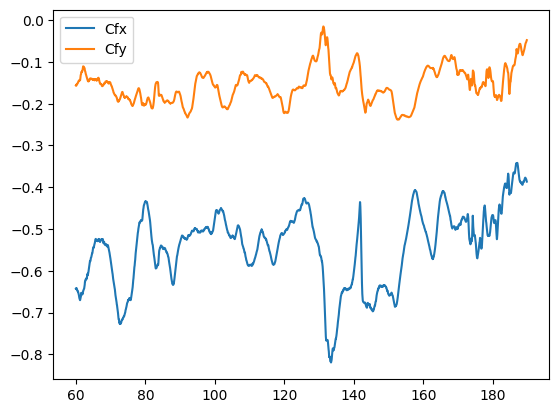

In [23]:
import matplotlib.pyplot as plt

df_floor = df[(df["floor"] == 10) & (df["time_step"] > 60)]
df_floor = df_floor.sort_values(by=["time_step"])

plt.plot(df_floor["time_step"], df_floor["fx"], label="Cfx")
plt.plot(df_floor["time_step"], df_floor["fy"], label="Cfy")
plt.legend()